<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Sebastián Ceballes


# Consigna
En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (volts)
su valor medio (volts)
la frecuencia (Hz)
la fase (radianes)
la cantidad de muestras digitalizada por el ADC (# muestras)
la frecuencia de muestreo del ADC.
es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)
Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarán todas las funciones de visualización estilo Matlab. Para usarlo:

import matplotlib.pyplot as plt
plt.plot(tt, xx)


# Resolución
fs=1000 Hz y N=1000 muestras
como 
\begin{equation}T_{0}=\frac{N}{f_{s}}
\end{equation}
T_0 = 1 segundo
Al configurar una ventana de exactamente $1$ segundo, garantizamos que cualquier señal con una frecuencia entera (como $1\text{ Hz}$, $50\text{ Hz}$ o $500\text{ Hz}$) completará un número exacto de ciclos dentro de nuestro vector.

### Análisis de Resultados: Teorema de Nyquist y Aliasing

Al digitalizar una señal, el **Teorema de Muestreo de Nyquist** establece que la frecuencia máxima que podemos representar correctamente sin pérdida de información es la mitad de nuestra frecuencia de muestreo ($f_s / 2$). Dado que nuestro sistema muestrea a $f_s = 1000 \text{ Hz}$, nuestro límite (frecuencia de Nyquist) es de **$500 \text{ Hz}$**. 

Los gráficos obtenidos demuestran qué ocurre al forzar este límite:

* **Frecuencia de $500 \text{ Hz}$:** Nos encontramos exactamente en el límite crítico. El sistema toma apenas dos muestras por ciclo, lo que deforma la reconstrucción de la onda original. Dependiendo de la fase, la señal puede incluso anularse (mostrando una línea recta en cero).
* **Frecuencias de $999 \text{ Hz}$, $1001 \text{ Hz}$ y $2001 \text{ Hz}$:** Al superar los $500 \text{ Hz}$, entramos en la zona de submuestreo y ocurre el fenómeno de **Aliasing** (plegado espectral). El sistema no toma suficientes "fotos" por segundo para capturar la verdadera velocidad de la onda. Como resultado matemático, estas tres señales rápidas se "disfrazan" y el sistema las percibe idénticas a una onda de baja frecuencia de exactamente **$1 \text{ Hz}$**.

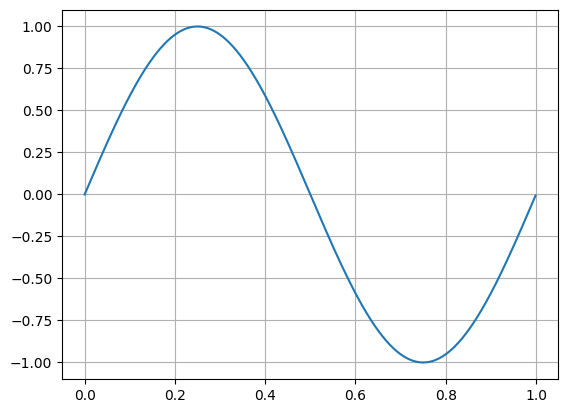

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Aug 12 20:29:08 2026

@author: Sebastian Ceballes
"""

import numpy as np
import matplotlib.pyplot as plt 
import scipy as sp


#%% Definiciones

#fs = 1000 # Hz
N = 1000  # Muestras

#%% Funciones

def mi_funcion_sen(vmax = 1, dc = 0, ff = 1, ph = 0, nn = N, fs = 1000):

   vector_tiempo = np.arange(0, nn/fs, 1/fs)

   xx = vmax * np.sin(2 * np.pi * ff * vector_tiempo + ph) + dc
  
   plt.plot(vector_tiempo, xx)
   plt.grid(True) 
   plt.show()
   
   return 


#%% Comienzo del script

mi_funcion_sen()


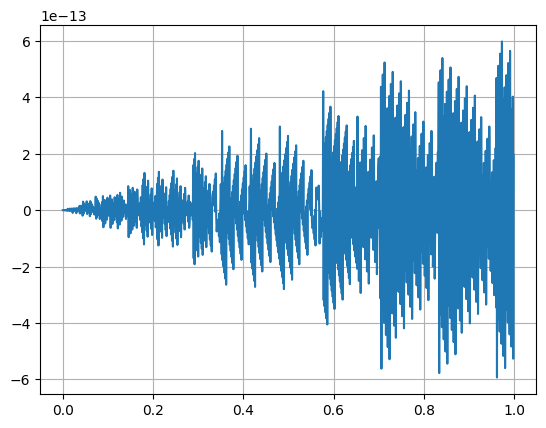

In [11]:
mi_funcion_sen(ff=500)

### ¿Qué está pasando realmente?
El límite de Nyquist en acción: Al muestrear una señal de $500\text{ Hz}$ a una frecuencia de muestreo ($f_s$) de $1000\text{ Hz}$. El sistema toma exactamente dos muestras por ciclo, cayendo matemáticamente justo en los cruces por cero de la onda senoidal ($\sin(0), \sin(\pi), \sin(2\pi)$, etc.).

El error de punto flotante: Matemáticamente, todos tus resultados deberían ser exactamente $0$. Sin embargo, como las computadoras no pueden almacenar el número $\pi$ con infinitos decimales, el cálculo de NumPy da resultados que son "casi cero" debido al redondeo de la máquina (ruido de punto flotante microscópico).

El auto-zoom de Matplotlib: Como la herramienta de ploteo está diseñada para auto-ajustarse a los datos, detecta esas variaciones diminutas y hace un zoom extremo. Lo que se ve es literalmente el error de precisión del procesador amplificado billones de veces.

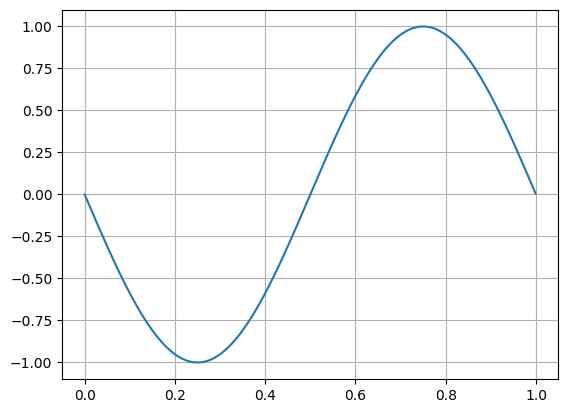

In [12]:
mi_funcion_sen(ff=999)

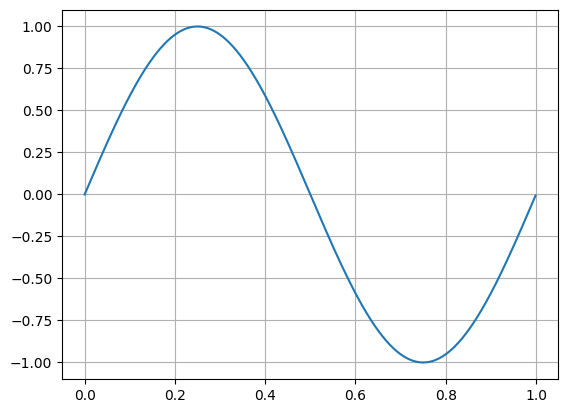

In [13]:
mi_funcion_sen(ff=1001)

### Implementación de Generador Adicional: Onda Cuadrada

Como señal propuesta para el generador extra, se diseñó una **onda cuadrada** utilizando el módulo `signal.square` de la librería `SciPy`.

La amplitud es de 2V y se tienen exactamente 5 ciclos por segundo 

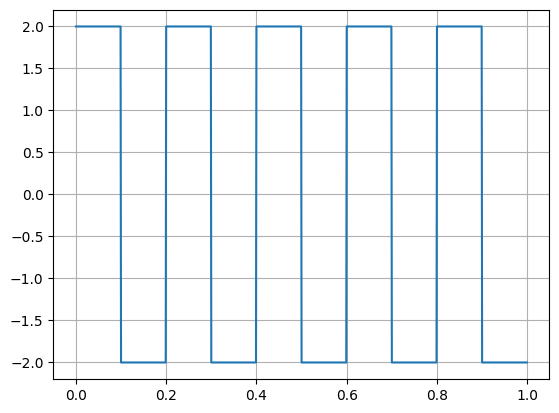

In [29]:
def mi_funcion_cuadrada (vmax = 2, dc = 0, ff = 5, ph = 0, nn = N, fs = 1000):
 
   vector_tiempo = np.arange(0, nn/fs, 1/fs)

   xx = vmax * sp.signal.square(2 * np.pi * ff * vector_tiempo + ph) + dc
  
   plt.plot(vector_tiempo, xx)
   plt.grid(True) 
   plt.show()
   
   return 
    
mi_funcion_cuadrada()